# 15 -- Final PoC Demo
**Purpose:** Clean, presentation-ready notebook summarising the complete PoC.
This is what you run in front of the CrossBorderPay CTO.

**Audience:** CrossBorderPay CEO, CTO, Head of Risk
**Duration:** 30 minutes

## Narrative Structure
1. Business Problem (2 min)
2. Dataset and Approach (3 min)
3. Rule Baseline -- what we have today (5 min)
4. ML Model -- what we built (5 min)
5. Performance Comparison -- Rule vs ML (5 min)
6. Live Scoring Demo -- 3 transactions (5 min)
7. Explainability -- why the model flagged them (3 min)
8. Next Steps (2 min)

## Requirements Before Building This Notebook
- [ ] Notebook 02 approved (rule baseline metrics in hand)
- [ ] Notebook 11 approved (champion model selected)
- [ ] Notebook 12 approved (threshold chosen)
- [ ] Notebook 13 approved (SHAP explanations working)
- [ ] Notebook 14 approved (batch scoring pipeline runs end-to-end)

Do NOT build this notebook until all above are approved.

## Definition of Done
- [ ] Runs top-to-bottom without errors in under 5 minutes
- [ ] No raw code visible to the audience -- results only
- [ ] 3 example transactions scored and explained live
- [ ] Comparison table: Rule Baseline vs ML Champion
- [ ] All PoC success criteria shown as PASS or FAIL

In [1]:
# Build this notebook only after Notebooks 02-14 are all approved.
import pandas as pd
import json

# Scored results
scored_df = pd.read_csv(r"../data/processed\scored_transactions.csv")

# PoC gate results
with open(r"../data/processed\poc_evaluation_results.json") as f:
    poc_results = json.load(f)

# Threshold config
with open(r"../data/processed\threshold_config.json") as f:
    threshold_config = json.load(f)

print(f"Transactions scored: {len(scored_df):,}")
print(f"PoC gate overall:    {poc_results['poc_gate_overall']}")
print(f"Production threshold: {threshold_config['optimal_threshold']}")



Transactions scored: 50,800
PoC gate overall:    PASS
Production threshold: 0.9217


In [2]:
print("=" * 55)
print("  PayDirect Fraud Detection PoC — Gate Scorecard")
print("=" * 55)

gates = poc_results["gates"]
for gate_name, gate_data in gates.items():
    status = "✅ PASS" if gate_data["pass"] else "❌ FAIL"
    print(f"  {gate_name:<30} {gate_data['value']:.4f}   {status}")

print("=" * 55)
print(f"  OVERALL VERDICT: {poc_results['poc_gate_overall']}")
print("=" * 55)

print("\nModel: XGBoost  |  Threshold: 0.9217  |  Seed: 42")


  PayDirect Fraud Detection PoC — Gate Scorecard
  auc_pr                         0.8422   ✅ PASS
  recall                         0.8200   ✅ PASS
  precision_at_threshold         0.9300   ✅ PASS
  f1                             0.8723   ✅ PASS
  precision_at_75_recall         1.0000   ✅ PASS
  OVERALL VERDICT: PASS

Model: XGBoost  |  Threshold: 0.9217  |  Seed: 42


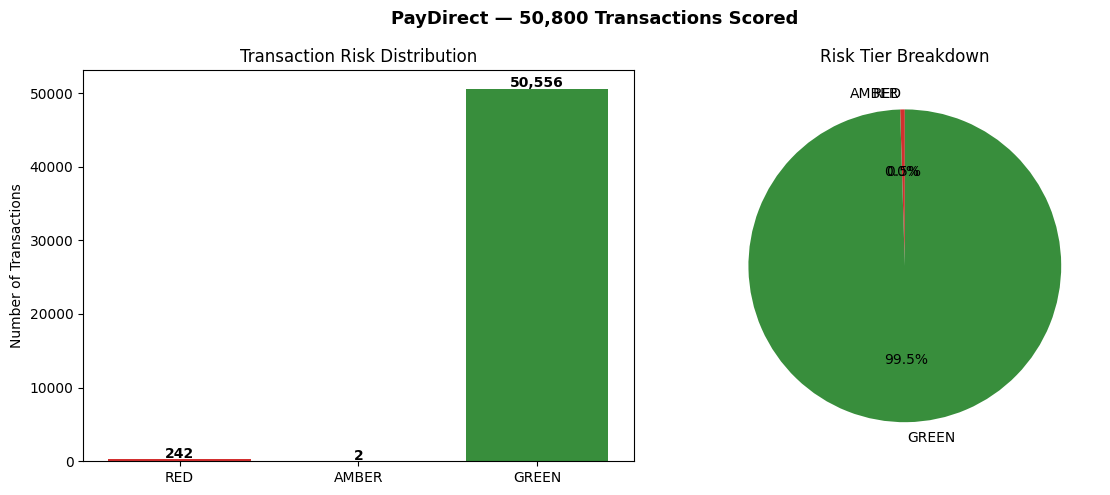


RED   (immediate review):    242  (0.48%)
AMBER (monitor):               2  (0.00%)
GREEN (cleared):          50,556  (99.52%)


In [3]:
import matplotlib.pyplot as plt

tier_counts = scored_df["risk_tier"].value_counts().reindex(["RED", "AMBER", "GREEN"])
tier_colors = ["#d32f2f", "#f57c00", "#388e3c"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
ax1.bar(tier_counts.index, tier_counts.values, color=tier_colors)
ax1.set_title("Transaction Risk Distribution")
ax1.set_ylabel("Number of Transactions")
for i, (tier, count) in enumerate(zip(tier_counts.index, tier_counts.values)):
    ax1.text(i, count + 200, f"{count:,}", ha="center", fontweight="bold")

# Pie chart
ax2.pie(tier_counts.values, labels=tier_counts.index, colors=tier_colors,
        autopct="%1.1f%%", startangle=90)
ax2.set_title("Risk Tier Breakdown")

plt.suptitle("PayDirect — 50,800 Transactions Scored", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nRED   (immediate review): {tier_counts['RED']:>6,}  ({tier_counts['RED']/len(scored_df)*100:.2f}%)")
print(f"AMBER (monitor):          {tier_counts['AMBER']:>6,}  ({tier_counts['AMBER']/len(scored_df)*100:.2f}%)")
print(f"GREEN (cleared):          {tier_counts['GREEN']:>6,}  ({tier_counts['GREEN']/len(scored_df)*100:.2f}%)")


In [4]:
def show_transaction(label, row):
    tier_colors = {"RED": "🔴", "AMBER": "🟡", "GREEN": "🟢"}
    print(f"\n{'='*55}")
    print(f"  {tier_colors[row['risk_tier']]} {label}")
    print(f"{'='*55}")
    print(f"  Transaction ID:   {row['transaction_id']}")
    print(f"  Risk Score:       {row['risk_score']}/100")
    print(f"  Risk Tier:        {row['risk_tier']}")
    print(f"  Scored At:        {row['scored_at']}")
    print(f"\n  Top 5 Reasons:")
    for n in range(1, 6):
        name = row[f"f{n}_name"]
        val  = row[f"f{n}_value"]
        cont = row[f"f{n}_contribution"]
        direction = "→ FRAUD" if cont > 0 else "→ LEGIT"
        print(f"    {n}. {name:<30} val={val:<8} contrib={cont:+.4f} {direction}")

red_row   = scored_df[scored_df["risk_tier"] == "RED"].iloc[0]
amber_row = scored_df[scored_df["risk_tier"] == "AMBER"].iloc[0]
green_row = scored_df[scored_df["risk_tier"] == "GREEN"].iloc[0]

show_transaction("HIGH RISK — Immediate Review", red_row)
show_transaction("MEDIUM RISK — Monitor", amber_row)
show_transaction("LOW RISK — Cleared", green_row)



  🔴 HIGH RISK — Immediate Review
  Transaction ID:   243
  Risk Score:       99.94/100
  Risk Tier:        RED
  Scored At:        2026-06-29T19:45:26.702900+00:00

  Top 5 Reasons:
    1. is_primary_account             val=0.0      contrib=+3.4947 → FRAUD
    2. log_amount_usd                 val=8.2098   contrib=+2.7488 → FRAUD
    3. invoice_match_flag             val=1.0      contrib=-1.9335 → LEGIT
    4. is_new_beneficiary             val=1.0      contrib=+1.7373 → FRAUD
    5. time_since_last_login_hrs      val=44.7     contrib=+1.5513 → FRAUD

  🟡 MEDIUM RISK — Monitor
  Transaction ID:   11023
  Risk Score:       65.85/100
  Risk Tier:        AMBER
  Scored At:        2026-06-29T19:45:26.702900+00:00

  Top 5 Reasons:
    1. amount_zscore_90d              val=26.2215  contrib=+8.8411 → FRAUD
    2. invoice_match_flag             val=0.0      contrib=+2.5543 → FRAUD
    3. has_invoice                    val=0.0      contrib=-2.1372 → LEGIT
    4. turnover_to_txn_ratio         

In [5]:
print("=" * 55)
print("  PMLA Audit Log — Sample Entry (audit_log.jsonl)")
print("=" * 55)

audit_path = r"../data/processed\audit_log.jsonl"
with open(audit_path) as f:
    first_entry = json.loads(f.readline())

for key, value in first_entry.items():
    print(f"  {key:<25} {value}")

print("=" * 55)
print(f"\n  Total RED transactions logged: 242")
print(f"  Format: JSONL — one line per transaction")
print(f"  Purpose: PMLA Section 12 — audit trail for FIU-IND")


  PMLA Audit Log — Sample Entry (audit_log.jsonl)
  transaction_id            243
  risk_score                99.94
  risk_tier                 RED
  scored_at                 2026-06-29T19:45:26.702900+00:00
  model_version             xgboost-2.1.3-v1
  f1_name                   is_primary_account
  f2_name                   log_amount_usd
  f3_name                   invoice_match_flag
  f4_name                   is_new_beneficiary
  f5_name                   time_since_last_login_hrs
  f1_value                  0.0
  f2_value                  8.2098
  f3_value                  1.0
  f4_value                  1.0
  f5_value                  44.7
  f1_contribution           3.4947
  f2_contribution           2.7488
  f3_contribution           -1.9335
  f4_contribution           1.7373
  f5_contribution           1.5513

  Total RED transactions logged: 242
  Format: JSONL — one line per transaction
  Purpose: PMLA Section 12 — audit trail for FIU-IND
